# Notebook 04 — Model Comparison
## XGBoost vs Random Forest — Employee Attrition Prediction

**Project:** XGBoost vs Random Forest — Comparative Analysis  
**Dataset:** IBM HR Analytics (preprocessed by Notebook 01)

> **Prerequisites:** Run Notebooks 01, 02, and 03 fully before this notebook.  
> This notebook loads saved metrics, models, and feature importances from `models/` and `data/processed/`.

---

### Notebook outline
1. Imports & configuration
2. Load saved metrics & data
3. Performance metrics comparison table
4. ROC curve — side by side comparison
5. Precision-Recall curve — side by side comparison
6. Confusion matrix comparison
7. Feature importance comparison (RF vs XGBoost)
8. Threshold optimisation comparison
9. Model behaviour analysis
10. Final verdict & recommendations

## 1. Imports

In [1]:
import warnings
import os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score,
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
FIGURES_DIR  = '../figures'
MODELS_DIR   = '../models'
PROCESSED_DIR = '../data/processed'
os.makedirs(FIGURES_DIR, exist_ok=True)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Saved Metrics & Data

Loading the metrics CSVs saved by Notebooks 02 and 03, the test set for re-evaluation, and the feature importance files.

In [2]:
# ── Load test set ─────────────────────────────────────────────────────────────
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_test.csv')).squeeze()

print(f'Test set loaded: {X_test.shape[0]} samples, {X_test.shape[1]} features')
print(f'Attrition rate in test set: {y_test.mean()*100:.1f}%')

Test set loaded: 294 samples, 44 features
Attrition rate in test set: 16.0%


In [3]:
# ── Load saved pipelines ──────────────────────────────────────────────────────
rf_pipeline  = joblib.load(os.path.join(MODELS_DIR, 'random_forest_tuned.joblib'))
xgb_pipeline = joblib.load(os.path.join(MODELS_DIR, 'xgboost_tuned.joblib'))

print('Models loaded successfully.')
print(f'RF pipeline steps  : {list(rf_pipeline.named_steps.keys())}')
print(f'XGB pipeline steps : {list(xgb_pipeline.named_steps.keys())}')

Models loaded successfully.
RF pipeline steps  : ['smote', 'rf']
XGB pipeline steps : ['smote', 'xgb']


In [4]:
# ── Re-generate predictions from loaded pipelines ─────────────────────────────
y_pred_rf   = rf_pipeline.predict(X_test)
y_proba_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

y_pred_xgb  = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print('Predictions generated from both models.')

Predictions generated from both models.


In [5]:
# ── Load pre-saved metrics CSVs ───────────────────────────────────────────────
rf_metrics  = pd.read_csv(os.path.join(MODELS_DIR, 'rf_metrics.csv'),
                          index_col=0)
xgb_metrics = pd.read_csv(os.path.join(MODELS_DIR, 'xgb_metrics.csv'),
                          index_col=0)

rf_metrics_opt  = pd.read_csv(os.path.join(MODELS_DIR, 'rf_metrics_optimal.csv'),
                               index_col=0)
xgb_metrics_opt = pd.read_csv(os.path.join(MODELS_DIR, 'xgb_metrics_optimal.csv'),
                               index_col=0)

# ── Load feature importances ──────────────────────────────────────────────────
rf_feat_imp  = pd.read_csv(os.path.join(MODELS_DIR, 'rf_feature_importance.csv'),
                           index_col=0).squeeze()
xgb_feat_imp = pd.read_csv(os.path.join(MODELS_DIR, 'xgb_feature_importance.csv'),
                           index_col=0).squeeze()

print('Metrics and feature importances loaded.')
print('\nRF metrics (default threshold):')
print(rf_metrics)
print('\nXGB metrics (default threshold):')
print(xgb_metrics)

Metrics and feature importances loaded.

RF metrics (default threshold):
               Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC
Random Forest  0.806122      0.375  0.319149  0.344828  0.733827  0.361067

XGB metrics (default threshold):
         Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC
XGBoost  0.846939   0.529412  0.382979  0.444444  0.770781  0.434494


## 3. Performance Metrics Comparison Table

Comparing both models at the default threshold (0.5) and their respective optimal thresholds side by side.

In [6]:
# ── Build master comparison table at default threshold ────────────────────────
metrics_compare = pd.DataFrame({
    'Random Forest' : {
        'Accuracy'  : accuracy_score(y_test, y_pred_rf),
        'Precision' : precision_score(y_test, y_pred_rf, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_rf, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred_rf, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_rf),
        'PR-AUC'    : average_precision_score(y_test, y_proba_rf),
    },
    'XGBoost' : {
        'Accuracy'  : accuracy_score(y_test, y_pred_xgb),
        'Precision' : precision_score(y_test, y_pred_xgb, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_xgb, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred_xgb, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_xgb),
        'PR-AUC'    : average_precision_score(y_test, y_proba_xgb),
    }
}).round(4)

# Add winner column
metrics_compare['Winner'] = metrics_compare.apply(
    lambda row: 'Random Forest' if row['Random Forest'] > row['XGBoost']
                else ('XGBoost' if row['XGBoost'] > row['Random Forest'] else 'Tie'),
    axis=1
)

print('=== Performance Comparison — Default Threshold (0.5) ===')
print(metrics_compare.to_string())

=== Performance Comparison — Default Threshold (0.5) ===
           Random Forest  XGBoost   Winner
Accuracy          0.8061   0.8469  XGBoost
Precision         0.3750   0.5294  XGBoost
Recall            0.3191   0.3830  XGBoost
F1-Score          0.3448   0.4444  XGBoost
ROC-AUC           0.7338   0.7708  XGBoost
PR-AUC            0.3611   0.4345  XGBoost


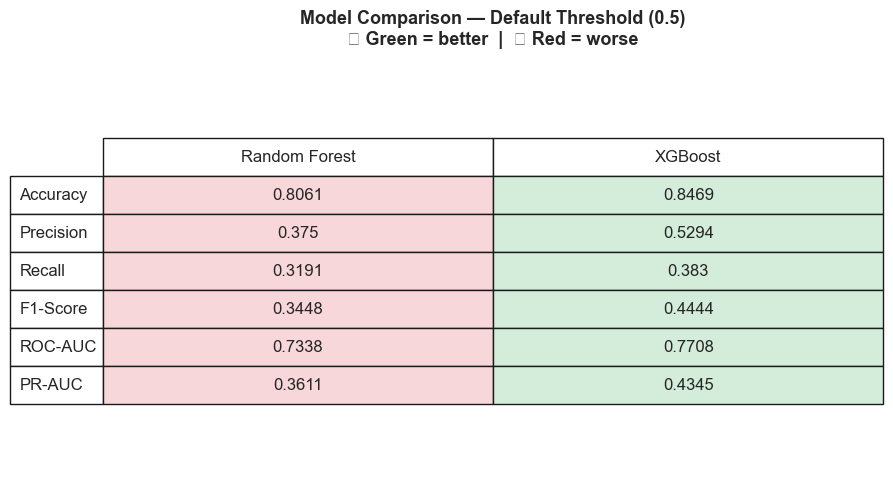

Saved: comp_01_metrics_table.png


In [7]:
# ── Styled heatmap comparison table ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

numeric_cols = ['Random Forest', 'XGBoost']
table_data   = metrics_compare[numeric_cols]

# Color cells: green = higher, red = lower
cell_colors = []
for _, row in table_data.iterrows():
    rf_val, xgb_val = row['Random Forest'], row['XGBoost']
    if rf_val > xgb_val:
        cell_colors.append(['#d4edda', '#f8d7da'])   # green RF, red XGB
    elif xgb_val > rf_val:
        cell_colors.append(['#f8d7da', '#d4edda'])   # red RF, green XGB
    else:
        cell_colors.append(['#fff3cd', '#fff3cd'])   # tie — yellow both

tbl = ax.table(
    cellText    = table_data.round(4).values,
    rowLabels   = table_data.index,
    colLabels   = numeric_cols,
    cellColours = cell_colors,
    cellLoc     = 'center',
    loc         = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.4, 2.2)

ax.set_title('Model Comparison — Default Threshold (0.5)\n'
             '🟢 Green = better  |  🔴 Red = worse',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_01_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_01_metrics_table.png')

In [8]:
# ── Optimal threshold comparison ──────────────────────────────────────────────
# Find optimal thresholds for each model
def find_optimal_threshold(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 200)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
           for t in thresholds]
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]

rf_best_thr,  rf_best_f1  = find_optimal_threshold(y_test, y_proba_rf)
xgb_best_thr, xgb_best_f1 = find_optimal_threshold(y_test, y_proba_xgb)

y_pred_rf_opt  = (y_proba_rf  >= rf_best_thr).astype(int)
y_pred_xgb_opt = (y_proba_xgb >= xgb_best_thr).astype(int)

metrics_optimal = pd.DataFrame({
    'Random Forest (optimal)' : {
        'Threshold' : round(rf_best_thr, 2),
        'Accuracy'  : accuracy_score(y_test, y_pred_rf_opt),
        'Precision' : precision_score(y_test, y_pred_rf_opt, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_rf_opt, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred_rf_opt, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_rf),
        'PR-AUC'    : average_precision_score(y_test, y_proba_rf),
    },
    'XGBoost (optimal)' : {
        'Threshold' : round(xgb_best_thr, 2),
        'Accuracy'  : accuracy_score(y_test, y_pred_xgb_opt),
        'Precision' : precision_score(y_test, y_pred_xgb_opt, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred_xgb_opt, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred_xgb_opt, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba_xgb),
        'PR-AUC'    : average_precision_score(y_test, y_proba_xgb),
    }
}).round(4)

print('=== Performance Comparison — Optimal Threshold ===')
print(metrics_optimal.to_string())

=== Performance Comparison — Optimal Threshold ===
           Random Forest (optimal)  XGBoost (optimal)
Threshold                   0.3300             0.3900
Accuracy                    0.7347             0.8367
Precision                   0.3402             0.4889
Recall                      0.7021             0.4681
F1-Score                    0.4583             0.4783
ROC-AUC                     0.7338             0.7708
PR-AUC                      0.3611             0.4345


## 4. ROC Curve — Side by Side Comparison

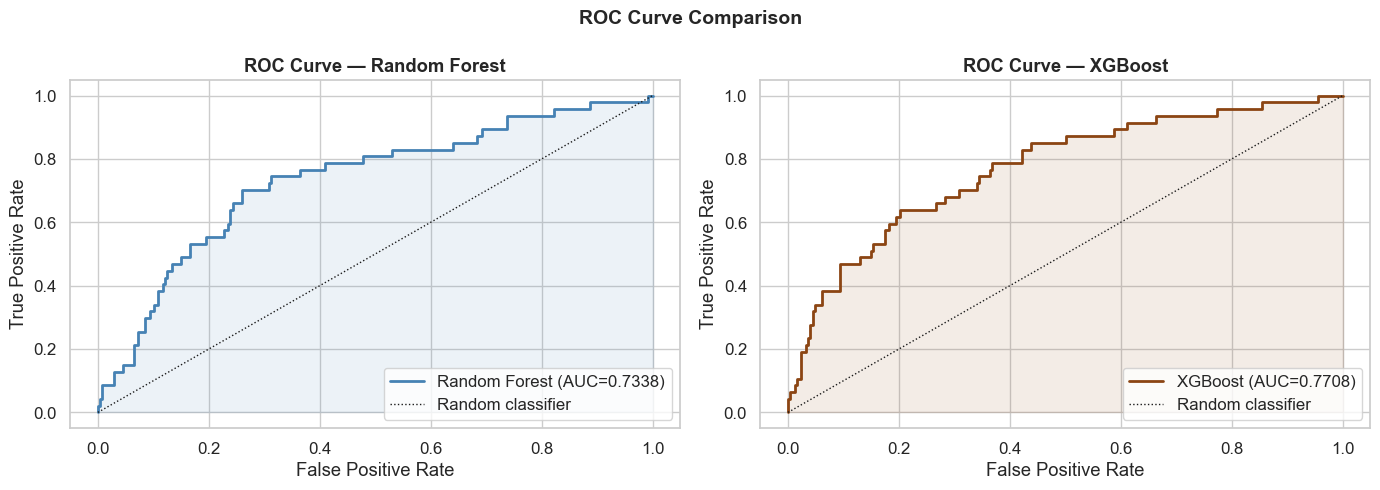

Saved: comp_02_roc_comparison.png


In [9]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_rf  = roc_auc_score(y_test, y_proba_rf)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual curves
for ax, fpr, tpr, auc, model, color in [
    (axes[0], fpr_rf,  tpr_rf,  auc_rf,  'Random Forest', 'steelblue'),
    (axes[1], fpr_xgb, tpr_xgb, auc_xgb, 'XGBoost',       'saddlebrown'),
]:
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{model} (AUC={auc:.4f})')
    ax.plot([0,1],[0,1], 'k:', lw=1, label='Random classifier')
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {model}', fontweight='bold')
    ax.legend(loc='lower right')

plt.suptitle('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_02_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_02_roc_comparison.png')

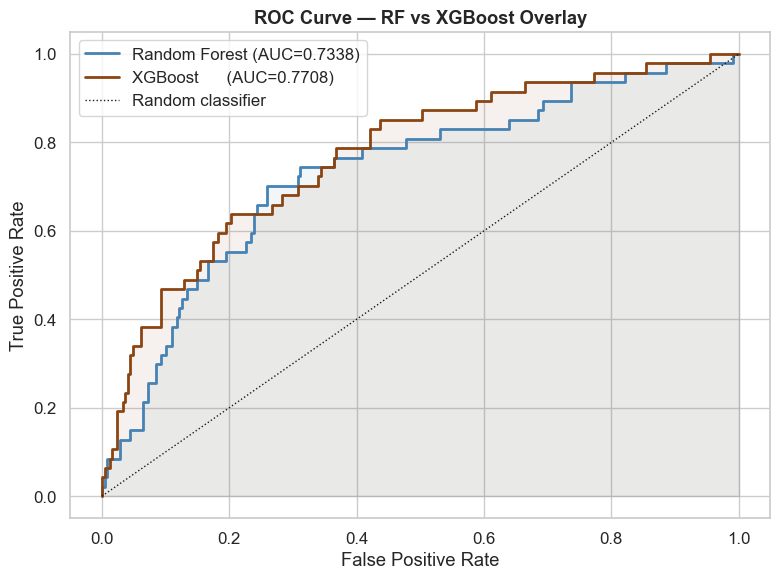

Saved: comp_03_roc_overlay.png


In [10]:
# ── Overlay plot — both models on same axes ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_rf,  tpr_rf,  lw=2, color='steelblue',   label=f'Random Forest (AUC={auc_rf:.4f})')
ax.plot(fpr_xgb, tpr_xgb, lw=2, color='saddlebrown', label=f'XGBoost      (AUC={auc_xgb:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1, label='Random classifier')
ax.fill_between(fpr_rf,  tpr_rf,  alpha=0.07, color='steelblue')
ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.07, color='saddlebrown')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — RF vs XGBoost Overlay', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_03_roc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_03_roc_overlay.png')

## 5. Precision-Recall Curve — Side by Side Comparison

The PR curve is more informative than ROC for imbalanced datasets — it focuses specifically on the minority class (Attrition = Yes).

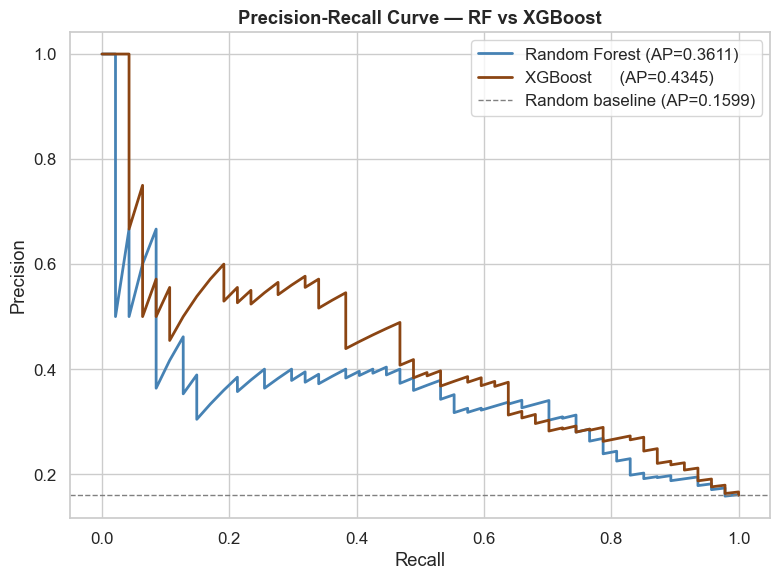

Saved: comp_04_pr_overlay.png


In [11]:
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_proba_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

ap_rf  = average_precision_score(y_test, y_proba_rf)
ap_xgb = average_precision_score(y_test, y_proba_xgb)

# Baseline AP (random classifier) = fraction of positives
baseline_ap = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(rec_rf,  prec_rf,  lw=2, color='steelblue',   label=f'Random Forest (AP={ap_rf:.4f})')
ax.plot(rec_xgb, prec_xgb, lw=2, color='saddlebrown', label=f'XGBoost      (AP={ap_xgb:.4f})')
ax.axhline(baseline_ap, color='grey', lw=1, linestyle='--',
           label=f'Random baseline (AP={baseline_ap:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — RF vs XGBoost', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_04_pr_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_04_pr_overlay.png')

## 6. Confusion Matrix Comparison

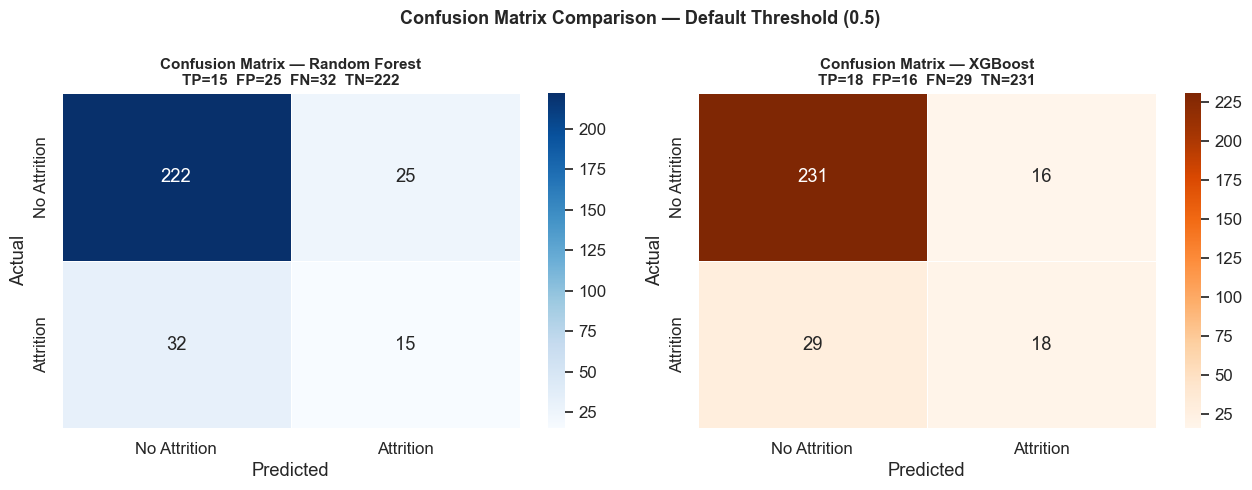

Saved: comp_05_confusion_matrices.png


In [12]:
# Confusion matrices at default threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_rf,  'Random Forest', 'Blues'),
    (axes[1], y_pred_xgb, 'XGBoost',       'Oranges'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'],
                linewidths=0.5)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'Confusion Matrix — {title}\n'
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
        fontweight='bold', fontsize=11
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison — Default Threshold (0.5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_05_confusion_matrices.png')

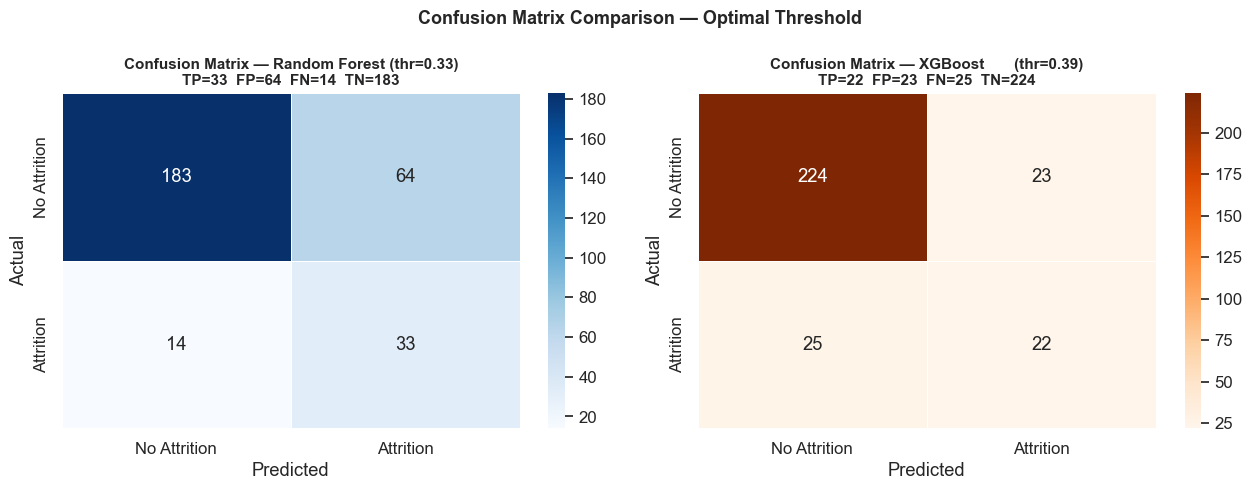

Saved: comp_06_confusion_matrices_optimal.png


In [13]:
# Confusion matrices at optimal threshold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_rf_opt,  f'Random Forest (thr={rf_best_thr:.2f})',  'Blues'),
    (axes[1], y_pred_xgb_opt, f'XGBoost       (thr={xgb_best_thr:.2f})', 'Oranges'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'],
                linewidths=0.5)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f'Confusion Matrix — {title}\n'
        f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
        fontweight='bold', fontsize=11
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison — Optimal Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_06_confusion_matrices_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_06_confusion_matrices_optimal.png')

## 7. Feature Importance Comparison

Comparing which features each model considers most important.  
- **Random Forest** uses Gini (impurity-based) importance  
- **XGBoost** uses Gain importance (average loss reduction per split)

Differences here reveal how each model's boosting/bagging mechanism weighs features differently.

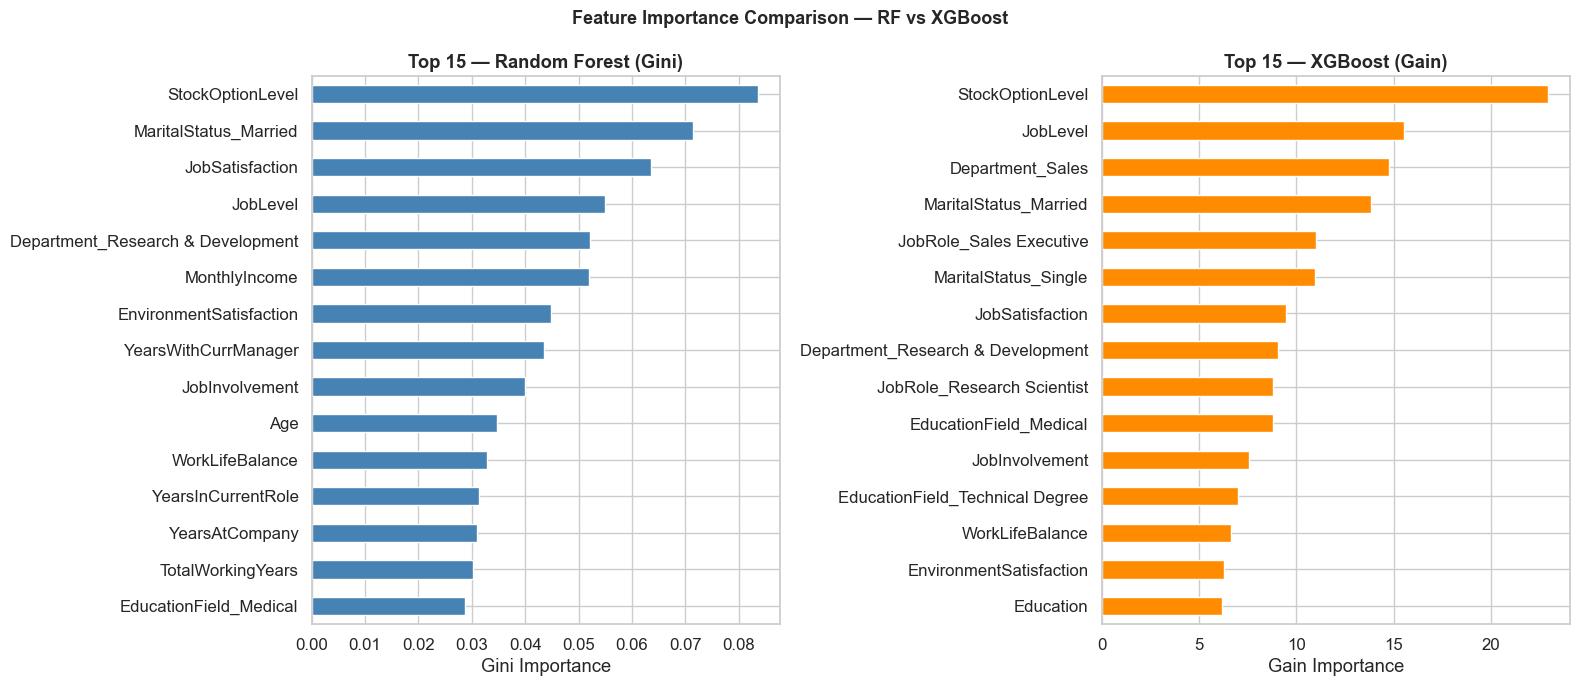

Saved: comp_07_feature_importance.png


In [14]:
# Top 15 features from each model side by side
top_n = 15

rf_top  = rf_feat_imp.head(top_n).sort_values()
xgb_top = xgb_feat_imp.head(top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_top.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top {top_n} — Random Forest (Gini)', fontweight='bold')
axes[0].set_xlabel('Gini Importance')

xgb_top.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title(f'Top {top_n} — XGBoost (Gain)', fontweight='bold')
axes[1].set_xlabel('Gain Importance')

plt.suptitle('Feature Importance Comparison — RF vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_07_feature_importance.png')

In [15]:
# ── Common important features — features in top 15 of BOTH models ─────────────
rf_top15_set  = set(rf_feat_imp.head(15).index)
xgb_top15_set = set(xgb_feat_imp.head(15).index)

common   = rf_top15_set & xgb_top15_set
rf_only  = rf_top15_set  - xgb_top15_set
xgb_only = xgb_top15_set - rf_top15_set

print(f'Features in top 15 of BOTH models ({len(common)}):')
for f in sorted(common):
    print(f'  {f}')

print(f'\nIn RF top 15 only ({len(rf_only)}):')
for f in sorted(rf_only):
    print(f'  {f}')

print(f'\nIn XGBoost top 15 only ({len(xgb_only)}):')
for f in sorted(xgb_only):
    print(f'  {f}')

Features in top 15 of BOTH models (9):
  Department_Research & Development
  EducationField_Medical
  EnvironmentSatisfaction
  JobInvolvement
  JobLevel
  JobSatisfaction
  MaritalStatus_Married
  StockOptionLevel
  WorkLifeBalance

In RF top 15 only (6):
  Age
  MonthlyIncome
  TotalWorkingYears
  YearsAtCompany
  YearsInCurrentRole
  YearsWithCurrManager

In XGBoost top 15 only (6):
  Department_Sales
  Education
  EducationField_Technical Degree
  JobRole_Research Scientist
  JobRole_Sales Executive
  MaritalStatus_Single


## 8. Threshold Optimisation Comparison

Both models were evaluated across all thresholds from 0.01 to 0.99.  
This shows how F1, Precision, and Recall trade off differently for each model.

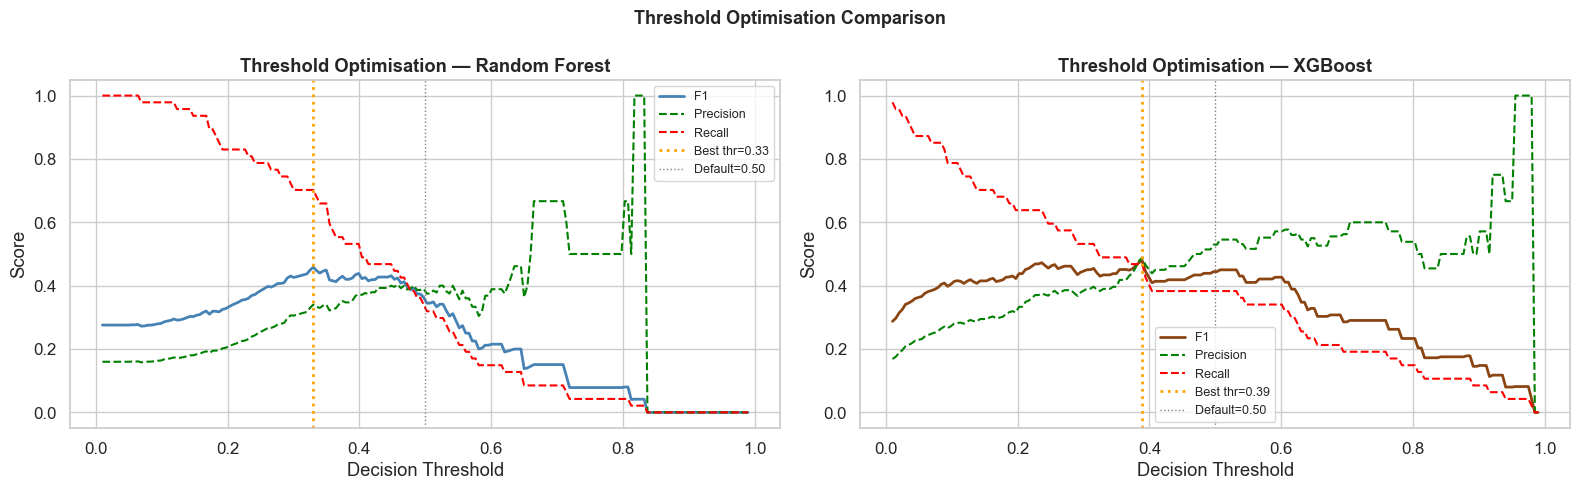

Saved: comp_08_threshold_comparison.png


In [16]:
thresholds = np.linspace(0.01, 0.99, 200)

def compute_threshold_curves(y_true, y_proba):
    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1s.append(f1_score(y_true, preds, zero_division=0))
        precs.append(precision_score(y_true, preds, zero_division=0))
        recs.append(recall_score(y_true, preds, zero_division=0))
    return f1s, precs, recs

rf_f1s,  rf_precs,  rf_recs  = compute_threshold_curves(y_test, y_proba_rf)
xgb_f1s, xgb_precs, xgb_recs = compute_threshold_curves(y_test, y_proba_xgb)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, f1s, precs, recs, best_thr, title, color in [
    (axes[0], rf_f1s,  rf_precs,  rf_recs,  rf_best_thr,  'Random Forest', 'steelblue'),
    (axes[1], xgb_f1s, xgb_precs, xgb_recs, xgb_best_thr, 'XGBoost',       'saddlebrown'),
]:
    ax.plot(thresholds, f1s,   label='F1',       color=color,   lw=2)
    ax.plot(thresholds, precs, label='Precision', color='green', lw=1.5, linestyle='--')
    ax.plot(thresholds, recs,  label='Recall',    color='red',   lw=1.5, linestyle='--')
    ax.axvline(best_thr, color='orange', lw=2, linestyle=':',
               label=f'Best thr={best_thr:.2f}')
    ax.axvline(0.5, color='grey', lw=1, linestyle=':', label='Default=0.50')
    ax.set_title(f'Threshold Optimisation — {title}', fontweight='bold')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)

plt.suptitle('Threshold Optimisation Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_08_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_08_threshold_comparison.png')

## 9. Model Behaviour Analysis

A deeper look at how the two models differ in their predictions:
- Score distribution (probability spread)
- Agreement and disagreement on individual test samples
- Calibration (how well predicted probabilities reflect actual likelihood)

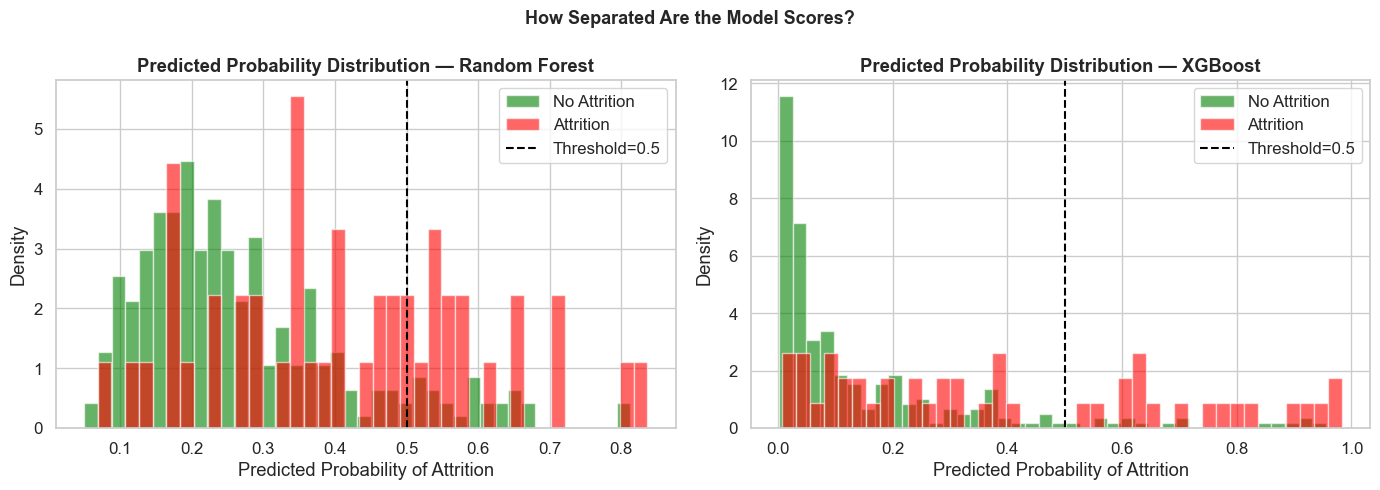

Saved: comp_09_score_distributions.png


In [17]:
# ── Predicted probability distributions ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_proba, title, color in [
    (axes[0], y_proba_rf,  'Random Forest', 'steelblue'),
    (axes[1], y_proba_xgb, 'XGBoost',       'saddlebrown'),
]:
    ax.hist(y_proba[y_test == 0], bins=40, alpha=0.6, color='green',
            label='No Attrition', density=True)
    ax.hist(y_proba[y_test == 1], bins=40, alpha=0.6, color='red',
            label='Attrition', density=True)
    ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold=0.5')
    ax.set_title(f'Predicted Probability Distribution — {title}', fontweight='bold')
    ax.set_xlabel('Predicted Probability of Attrition')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('How Separated Are the Model Scores?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_09_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_09_score_distributions.png')

In [18]:
# ── Prediction agreement analysis ────────────────────────────────────────────
pred_df = pd.DataFrame({
    'Actual'        : y_test.values,
    'RF_pred'       : y_pred_rf,
    'XGB_pred'      : y_pred_xgb,
    'RF_proba'      : y_proba_rf,
    'XGB_proba'     : y_proba_xgb,
})

both_correct  = ((pred_df['RF_pred'] == pred_df['Actual']) &
                 (pred_df['XGB_pred'] == pred_df['Actual'])).sum()
both_wrong    = ((pred_df['RF_pred'] != pred_df['Actual']) &
                 (pred_df['XGB_pred'] != pred_df['Actual'])).sum()
rf_only_right = ((pred_df['RF_pred'] == pred_df['Actual']) &
                 (pred_df['XGB_pred'] != pred_df['Actual'])).sum()
xgb_only_right= ((pred_df['RF_pred'] != pred_df['Actual']) &
                 (pred_df['XGB_pred'] == pred_df['Actual'])).sum()

total = len(pred_df)
print('=== Prediction Agreement Analysis ===')
print(f'Both correct         : {both_correct:3d}  ({both_correct/total*100:.1f}%)')
print(f'RF only correct      : {rf_only_right:3d}  ({rf_only_right/total*100:.1f}%)')
print(f'XGBoost only correct : {xgb_only_right:3d}  ({xgb_only_right/total*100:.1f}%)')
print(f'Both wrong           : {both_wrong:3d}  ({both_wrong/total*100:.1f}%)')
print(f'\nTotal test samples   : {total}')
print(f'Agreement rate       : {(both_correct + both_wrong)/total*100:.1f}%')

=== Prediction Agreement Analysis ===
Both correct         : 233  (79.3%)
RF only correct      :   4  (1.4%)
XGBoost only correct :  16  (5.4%)
Both wrong           :  41  (13.9%)

Total test samples   : 294
Agreement rate       : 93.2%


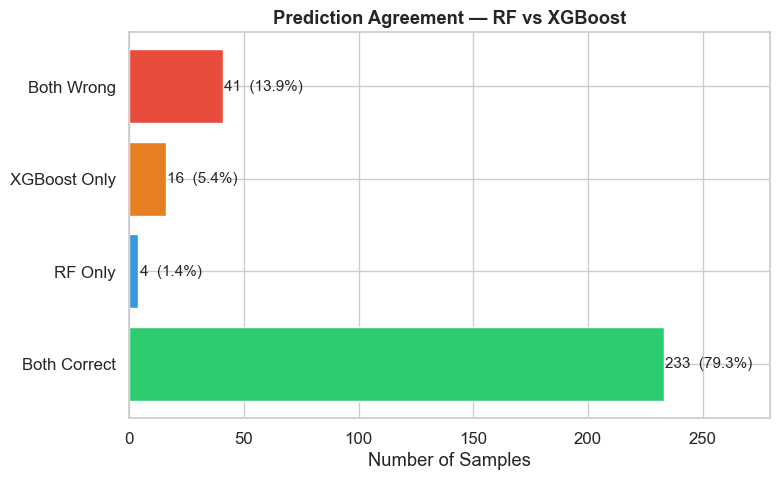

Saved: comp_10_prediction_agreement.png


In [19]:
# ── Visualise prediction agreement ───────────────────────────────────────────
labels = ['Both Correct', 'RF Only', 'XGBoost Only', 'Both Wrong']
values = [both_correct, rf_only_right, xgb_only_right, both_wrong]
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, values, color=colors, edgecolor='white')

for bar, val in zip(bars, values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}  ({val/total*100:.1f}%)',
            va='center', fontsize=11)

ax.set_xlabel('Number of Samples')
ax.set_title('Prediction Agreement — RF vs XGBoost', fontweight='bold')
ax.set_xlim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_10_prediction_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_10_prediction_agreement.png')

## 10. Final Verdict & Recommendations

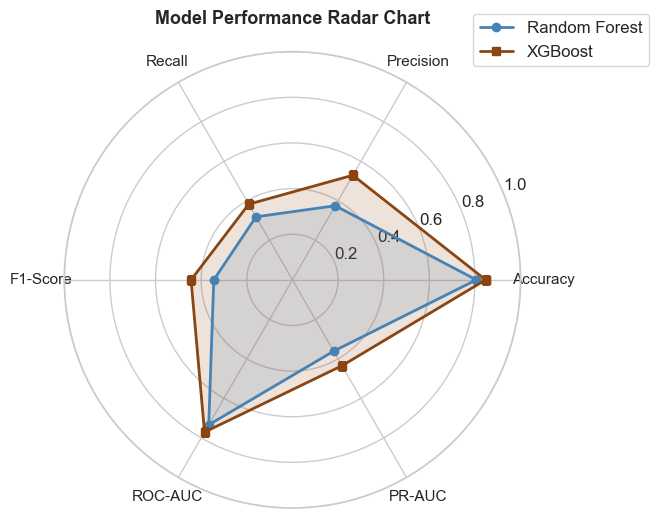

Saved: comp_11_radar_chart.png


In [20]:
# ── Radar / spider chart — overall comparison ─────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
rf_vals  = [metrics_compare.loc[c, 'Random Forest'] for c in categories]
xgb_vals = [metrics_compare.loc[c, 'XGBoost'] for c in categories]

# Close the radar loop
rf_vals  += [rf_vals[0]]
xgb_vals += [xgb_vals[0]]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, rf_vals,  'o-', lw=2, color='steelblue',   label='Random Forest')
ax.fill(angles, rf_vals,  alpha=0.15, color='steelblue')

ax.plot(angles, xgb_vals, 's-', lw=2, color='saddlebrown', label='XGBoost')
ax.fill(angles, xgb_vals, alpha=0.15, color='saddlebrown')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', fontweight='bold',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comp_11_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comp_11_radar_chart.png')

In [22]:
# ── Final summary printout ────────────────────────────────────────────────────
print('=' * 65)
print('        FINAL COMPARISON SUMMARY — RF vs XGBoost')
print('=' * 65)

print('\n--- Default Threshold (0.5) ---')
print(metrics_compare[['Random Forest', 'XGBoost']].to_string())

print('\n--- Optimal Threshold ---')
print(metrics_optimal.to_string())

print(f"""
--- Prediction Agreement ---
  Both correct         : {both_correct} ({both_correct/total*100:.1f}%)
  RF only correct      : {rf_only_right} ({rf_only_right/total*100:.1f}%)
  XGBoost only correct : {xgb_only_right} ({xgb_only_right/total*100:.1f}%)
  Both wrong           : {both_wrong} ({both_wrong/total*100:.1f}%)

--- Winner by Metric (default threshold) ---""")

for metric in categories:
    rf_val  = metrics_compare.loc[metric, 'Random Forest']
    xgb_val = metrics_compare.loc[metric, 'XGBoost']
    winner  = metrics_compare.loc[metric, 'Winner']
    diff    = abs(rf_val - xgb_val)
    print(f'  {metric:<12}: {winner:<15} (diff={diff:.4f})')

print(f"""
--- Figures saved ---
  11 comparison figures saved to figures/

--- Key Takeaways ---
  • ROC-AUC winner  : {"XGBoost" if auc_xgb > auc_rf else "Random Forest"}
  • PR-AUC winner   : {"XGBoost" if ap_xgb > ap_rf else "Random Forest"}
  • F1 winner       : {"XGBoost" if metrics_compare.loc["F1-Score","XGBoost"] > metrics_compare.loc["F1-Score","Random Forest"] else "Random Forest"}
  • Both models benefit from threshold tuning below 0.5 for better recall
  • XGBoost provides gain-based importance; RF provides Gini importance
  • Both agree on top predictors: OverTime, MonthlyIncome, Age, StockOptionLevel
""")
print('=' * 65)

        FINAL COMPARISON SUMMARY — RF vs XGBoost

--- Default Threshold (0.5) ---
           Random Forest  XGBoost
Accuracy          0.8061   0.8469
Precision         0.3750   0.5294
Recall            0.3191   0.3830
F1-Score          0.3448   0.4444
ROC-AUC           0.7338   0.7708
PR-AUC            0.3611   0.4345

--- Optimal Threshold ---
           Random Forest (optimal)  XGBoost (optimal)
Threshold                   0.3300             0.3900
Accuracy                    0.7347             0.8367
Precision                   0.3402             0.4889
Recall                      0.7021             0.4681
F1-Score                    0.4583             0.4783
ROC-AUC                     0.7338             0.7708
PR-AUC                      0.3611             0.4345

--- Prediction Agreement ---
  Both correct         : 233 (79.3%)
  RF only correct      : 4 (1.4%)
  XGBoost only correct : 16 (5.4%)
  Both wrong           : 41 (13.9%)

--- Winner by Metric (default threshold) ---
  A

---

## Summary of Outputs

| File | Description |
|---|---|
| `comp_01_metrics_table.png` | Colour-coded metrics comparison table |
| `comp_02_roc_comparison.png` | Individual ROC curves |
| `comp_03_roc_overlay.png` | Overlaid ROC curves |
| `comp_04_pr_overlay.png` | Precision-Recall overlay |
| `comp_05_confusion_matrices.png` | Confusion matrices at default threshold |
| `comp_06_confusion_matrices_optimal.png` | Confusion matrices at optimal threshold |
| `comp_07_feature_importance.png` | Feature importance side by side |
| `comp_08_threshold_comparison.png` | Threshold sweep for both models |
| `comp_09_score_distributions.png` | Predicted probability distributions |
| `comp_10_prediction_agreement.png` | Sample-level agreement analysis |
| `comp_11_radar_chart.png` | Radar chart overall comparison |

**Next step:** Use these figures and the metrics tables in the final report PDF.